<div style="background:linear-gradient(135deg,#7c2d12 0%,#c2410c 55%,#fb923c 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fed7aa;font-weight:700;text-transform:uppercase">Chapter 188 &middot; Capstone 27 &middot; Logistic Regression</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Clinical Risk Scoring</div>
  <div style="font-size:15px;color:#fed7aa;max-width:820px;line-height:1.6">Two models with the same AUC to four decimal places. One says four percent of these patients are in danger and one says nine. A score that sends people home has to be right about the level, and AUC cannot see the level at all.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss, roc_curve
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
OR, DK, LT, MUT, GD, RD = "#c2410c", "#7c2d12", "#fb923c", "#94a3b8", "#047857", "#dc2626"

BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-clinical-risk-scoring.xlsx"
def load(sheet):
    try:    return pd.read_excel("../../data/" + fn, sheet_name=sheet)
    except FileNotFoundError: return pd.read_excel(BASE + fn, sheet_name=sheet)
raw  = load("Presentations")
plan = load("AnalysisPlan")
print("rows in the extract:", f"{len(raw):,}")
raw.head()

rows in the extract: 9,060


,patient_id,age,sex,systolic_bp,heart_rate,troponin_ng_l,diabetes,current_smoker,prior_mi,ecg_ischemia,arrival_month,major_event_30d
0,E705388,60,Male,168,90,9.4,0,0,0,0,9,0
1,E701394,74,Female,170,73,7.5,0,0,0,0,2,0
2,E707492,48,Female,154,56,2.0,0,0,0,0,12,0
3,E707082,92,Female,146,58,1.3,0,0,0,0,7,0
4,E706870,60,Male,151,95,2.6,0,0,0,0,6,0


## Step 1 &middot; The decision the score is for

In [2]:
for line in plan.analysis_plan.fillna(""):
    print(line)

AGREED WITH THE CLINICAL LEAD BEFORE MODELING.

THE DECISION. A patient scored above the threshold is admitted for observation. Below it they
are discharged with advice. The score is not a research output, it is a rule that sends people
home, so it has to be right about the LEVEL of risk and not merely about the ordering.

C1 OUTCOME: a major cardiac event within 30 days of presentation.
C2 MODEL: logistic regression on age, sex, systolic BP, heart rate, troponin, diabetes,
   smoking, prior myocardial infarction and ECG ischemia.
C3 VALIDATION: a held-out test set. Every number below is computed on data the model has
   never seen. Discrimination measured on the training set is not evidence of anything.
C4 DISCRIMINATION: the area under the ROC curve. Reported because everyone asks for it, and
   understood to answer only the question 'does it rank patients correctly'.
C5 CALIBRATION: THE PART THAT MATTERS HERE. A calibration plot, the calibration slope and
   intercept, and the Brier

**Read C5 and C6 together.** A score that ranks patients correctly but reports the wrong level of risk will place the threshold in the wrong place, and the threshold is the entire product. Nobody in an emergency department consumes a ranking; they consume a decision about one patient in front of them.

## Step 2 &middot; Cleaning

In [3]:
d = raw.drop_duplicates(subset="patient_id").copy()
print(f"raw rows                {len(raw):,}")
print(f"after the duplicate extract {len(d):,}")
d.loc[d.systolic_bp == 0, "systolic_bp"] = np.nan      # cuff fault, not a blood pressure
d.loc[d.heart_rate == 999, "heart_rate"] = np.nan      # monitor sentinel
d = d.dropna(subset=["systolic_bp", "heart_rate"])
print(f"after voiding vitals sentinels {len(d):,}")

d["trop_missing"] = d.troponin_ng_l.isna().astype(int)
d["trop"] = np.log1p(d.troponin_ng_l.fillna(d.troponin_ng_l.median()))
d["male"] = (d.sex == "Male").astype(int)
print(f"\ntroponin assay not run  {d.trop_missing.sum()}   kept, with an indicator")
print(f"event rate              {d.major_event_30d.mean():.2%}   "
      f"({d.major_event_30d.sum()} events in {len(d):,} presentations)")

raw rows                9,060
after the duplicate extract 9,000
after voiding vitals sentinels 8,938

troponin assay not run  138   kept, with an indicator
event rate              3.94%   (352 events in 8,938 presentations)


**A missing troponin is kept, not dropped.** An assay that was not ordered tells you something about how the patient presented, so the indicator goes into the model. Dropping those 138 people would quietly restrict the score to patients somebody already thought were worth testing.

## Step 3 &middot; Fit, and hold data back

In [4]:
F = ["age","male","systolic_bp","heart_rate","trop","trop_missing",
     "diabetes","current_smoker","prior_mi","ecg_ischemia"]
X, y = d[F].values.astype(float), d.major_event_30d.values
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.35, random_state=7, stratify=y)
mu, sd = Xtr.mean(0), Xtr.std(0)
model = LogisticRegression(max_iter=4000, C=1e6).fit((Xtr-mu)/sd, ytr)
pA = model.predict_proba((Xte-mu)/sd)[:, 1]
print(f"train {len(ytr):,} ({ytr.mean():.2%} events)    test {len(yte):,} ({yte.mean():.2%} events)")
print("\nevery number from here is computed on the held-out test set.")

train 5,809 (3.94% events)    test 3,129 (3.93% events)

every number from here is computed on the held-out test set.


## Step 4 &middot; The metric everyone asks for, and what it cannot see

To make the point concretely, build a second model that ranks every patient in exactly the same order and is wrong about the level. Adding a constant to the log-odds does precisely that: it cannot change any patient's position in the queue.

In [5]:
lo = np.log(pA/(1-pA))
pB = 1/(1 + np.exp(-(lo + 0.95)))          # identical ordering, inflated level

print(f"{'':32s}{'AUC':>9}{'Brier':>10}{'mean predicted':>16}{'observed':>11}")
for nm, p in [("A  calibrated", pA), ("B  same ranking, inflated", pB)]:
    print(f"{nm:32s}{roc_auc_score(yte, p):>9.4f}{brier_score_loss(yte, p):>10.5f}"
          f"{p.mean():>16.2%}{yte.mean():>11.2%}")
print("\nSpearman correlation between the two sets of predictions: "
      f"{pd.Series(pA).corr(pd.Series(pB), method='spearman'):.6f}")

                                      AUC     Brier  mean predicted   observed
A  calibrated                      0.8097   0.03448           3.93%      3.93%
B  same ranking, inflated          0.8097   0.03944           8.64%      3.93%

Spearman correlation between the two sets of predictions: 1.000000


**The AUCs are identical to four decimal places, and they should be.** AUC asks one question: given a patient who had an event and one who did not, how often does the model score the first one higher? That is a question about *order*, and adding a constant to every log-odds cannot change any patient's position in the queue.

Model B says **8.6 percent** of these patients will have an event. The true figure is **3.9 percent**. It is wrong by more than a factor of two, and the metric that gets quoted in every paper and every model card cannot detect it.

The Brier score does notice, because it scores the probabilities rather than the ranking.

## Step 5 &middot; Calibration, measured properly

The Brier score notices but does not localize. A calibration plot and the calibration slope and intercept say *where* and *how* a model is wrong.

In [6]:
def calibration(p, y, label):
    lp = np.log(p/(1-p))
    fit = sm.Logit(y, sm.add_constant(lp)).fit(disp=0)
    a, b = fit.params[0], fit.params[1]
    print(f"{label:30s} intercept {a:+.3f}   slope {b:.3f}")
    return a, b

print("ideal: intercept 0 (right level), slope 1 (right spread)\n")
calibration(pA, yte, "A  calibrated")
calibration(pB, yte, "B  same ranking, inflated")

print("\nBy decile of predicted risk, model A:\n")
q = pd.qcut(pA, 10, labels=False, duplicates="drop")
tab = pd.DataFrame({"pred": pA, "obs": yte, "bin": q}).groupby("bin").agg(
    n=("obs","size"), predicted=("pred","mean"), observed=("obs","mean"))
print((tab.assign(predicted=lambda t: (t.predicted*100).round(2),
                  observed=lambda t: (t.observed*100).round(2))).to_string())

ideal: intercept 0 (right level), slope 1 (right spread)

A  calibrated                  intercept -0.053   slope 0.980
B  same ranking, inflated      intercept -0.983   slope 0.980

By decile of predicted risk, model A:

       n  predicted  observed
bin                          
0    313       0.28      0.00
1    313       0.57      0.00
2    313       0.88      0.96
3    313       1.19      0.96
4    313       1.63      2.56
5    312       2.20      2.24
6    313       3.08      4.15
7    313       4.48      4.47
8    313       7.01      7.03
9    313      17.99     16.93


**Both models have a slope of 0.98, and that is the point.** The slope measures whether the *spread* of predicted risks is right, and B inherited A's spread exactly. The intercept measures whether the *level* is right, and B's is &#8722;0.98 against an ideal of zero.

Two numbers, and only one of them notices. A model card reporting AUC and slope would pass model B without comment.

## Step 6 &middot; Accuracy, and why nobody should quote it here

In [7]:
print(f"a rule that admits NOBODY gets accuracy {1 - yte.mean():.2%}")
print(f"and misses all {yte.sum()} events.\n")
print("With a 3.9 percent event rate, accuracy rewards a model for saying no.")
print("It is the wrong summary for any decision where the two errors differ in cost.")

a rule that admits NOBODY gets accuracy 96.07%
and misses all 123 events.

With a 3.9 percent event rate, accuracy rewards a model for saying no.
It is the wrong summary for any decision where the two errors differ in cost.


## Step 7 &middot; The threshold comes from costs, not from the data

A threshold is a statement about how much worse one error is than the other. That ratio is a clinical judgment, and the arithmetic that turns it into a number is one line.

In [8]:
RATIO = 40          # a missed event is judged 40 times worse than an unnecessary night
threshold = 1/(1 + RATIO)
print(f"clinicians judge a missed event {RATIO} times worse than an unnecessary admission")
print(f"threshold = 1/(1+{RATIO}) = {threshold:.4f}, so admit above {threshold*100:.1f}% risk\n")

print(f"{'':28s}{'admitted':>10}{'caught':>9}{'missed':>9}{'admit rate':>13}")
res = {}
for nm, p in [("model A, calibrated", pA), ("model B, inflated", pB)]:
    adm = p >= threshold
    caught, missed = int(yte[adm].sum()), int(yte.sum() - yte[adm].sum())
    res[nm] = (adm.sum(), caught, missed)
    print(f"  {nm:26s}{adm.sum():>10}{caught:>9}{missed:>9}{adm.mean():>12.1%}")

extra_adm = res["model B, inflated"][0] - res["model A, calibrated"][0]
extra_caught = res["model B, inflated"][1] - res["model A, calibrated"][1]
print(f"\nModel B admits {extra_adm} more patients and catches {extra_caught} more events:")
print(f"   {extra_adm/extra_caught:.0f} extra admissions per extra event caught.")

clinicians judge a missed event 40 times worse than an unnecessary admission
threshold = 1/(1+40) = 0.0244, so admit above 2.4% risk

                              admitted   caught   missed   admit rate
  model A, calibrated             1305      105       18       41.7%
  model B, inflated               2256      123        0       72.1%

Model B admits 951 more patients and catches 18 more events:
   53 extra admissions per extra event caught.


**Model B misses nothing, and that is not the good news it looks like.** It buys those eighteen events at fifty-three extra admissions each. The clinicians said forty. **A miscalibrated model does not become more cautious, it silently applies a different threshold than the one the clinical team chose**, and nobody in the room knows the trade-off has been changed.

That is the practical damage calibration error does. It does not show up as a worse ranking. It shows up as a rule that no longer implements the decision it was asked to implement.

## Step 8 &middot; Decision curve analysis

The threshold above rests on one cost ratio. Reasonable clinicians will disagree about it, so evaluate across a range. Net benefit puts true positives and false positives on one scale using the threshold itself as the exchange rate, and compares any rule against the two strategies it must beat: admit everyone, and admit nobody.

In [9]:
def net_benefit(p, y, t):
    adm = p >= t
    tp = int((y[adm] == 1).sum()); fp = int((y[adm] == 0).sum()); n = len(y)
    return tp/n - (fp/n)*(t/(1-t))

print(f"{'threshold':>10}{'model A':>10}{'model B':>10}{'admit all':>12}{'admit none':>12}")
for t_ in (0.01, 0.0244, 0.04, 0.07, 0.10, 0.15):
    nb_all = yte.mean() - (1-yte.mean())*(t_/(1-t_))
    print(f"{t_:>10.4f}{net_benefit(pA,yte,t_):>10.4f}{net_benefit(pB,yte,t_):>10.4f}"
          f"{nb_all:>12.4f}{0.0:>12.4f}")

 threshold   model A   model B   admit all  admit none
    0.0100    0.0319    0.0305      0.0296      0.0000
    0.0244    0.0240    0.0223      0.0153      0.0000
    0.0400    0.0174    0.0148     -0.0007      0.0000
    0.0700    0.0116    0.0052     -0.0330      0.0000
    0.1000    0.0069    0.0003     -0.0674      0.0000
    0.1500    0.0053   -0.0037     -0.1302      0.0000


**Model A is better at every threshold anybody would choose**, and the gap widens as the threshold rises. Admitting everyone is worse than doing nothing above about a 4 percent threshold, which is a useful sanity check on the whole exercise: a score only earns its place by beating both trivial strategies across the range of costs clinicians actually hold.

## Step 9 &middot; The decoy

In [10]:
Fd = F + ["arrival_month"]
Xd = d[Fd].values.astype(float)
Xdtr, Xdte, _, _ = train_test_split(Xd, y, test_size=0.35, random_state=7, stratify=y)
mud, sdd = Xdtr.mean(0), Xdtr.std(0)
md_ = LogisticRegression(max_iter=4000, C=1e6).fit((Xdtr-mud)/sdd, ytr)
pD = md_.predict_proba((Xdte-mud)/sdd)[:, 1]
print(f"AUC without arrival month  {roc_auc_score(yte, pA):.4f}")
print(f"AUC with arrival month     {roc_auc_score(yte, pD):.4f}")
print(f"\ncoefficient on arrival month: {md_.coef_[0][-1]:+.4f}  (the truth is exactly 0)")
print("A variable with no effect contributes nothing on held-out data. Had we judged it")
print("on the training set it would have looked like a small improvement, every time.")

AUC without arrival month  0.8097
AUC with arrival month     0.8091

coefficient on arrival month: +0.0458  (the truth is exactly 0)
A variable with no effect contributes nothing on held-out data. Had we judged it
on the training set it would have looked like a small improvement, every time.


## Step 10 &middot; The pictures

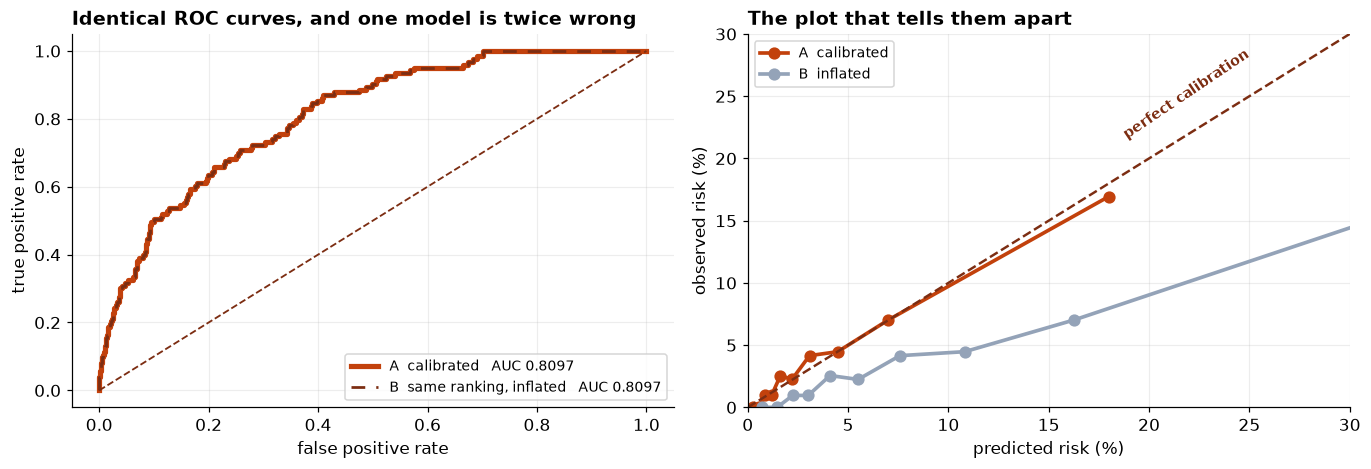

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))

ax = axes[0]
for nm, p, col, st, w in [("A  calibrated", pA, OR, "-", 3.4),
                          ("B  same ranking, inflated", pB, DK, (0, (5, 4)), 1.8)]:
    fpr, tpr, _ = roc_curve(yte, p)
    ax.plot(fpr, tpr, color=col, lw=w, ls=st, label=f"{nm}   AUC {roc_auc_score(yte,p):.4f}")
ax.plot([0,1], [0,1], color=DK, lw=1.2, ls="--")
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
ax.set_title("Identical ROC curves, and one model is twice wrong")
ax.legend(fontsize=9, loc="lower right")

ax = axes[1]
for nm, p, col in [("A  calibrated", pA, OR), ("B  inflated", pB, MUT)]:
    q = pd.qcut(p, 10, labels=False, duplicates="drop")
    t = pd.DataFrame({"p": p, "y": yte, "q": q}).groupby("q").agg(pr=("p","mean"), ob=("y","mean"))
    ax.plot(t.pr*100, t.ob*100, "o-", color=col, lw=2.4, ms=7, label=nm)
lim = 30
ax.plot([0, lim], [0, lim], color=DK, lw=1.6, ls="--")
ax.text(lim*0.62, lim*0.72, "perfect calibration", color=DK, fontsize=9, fontweight="bold", rotation=34)
ax.set_xlabel("predicted risk (%)"); ax.set_ylabel("observed risk (%)")
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_title("The plot that tells them apart"); ax.legend(fontsize=9, loc="upper left")
plt.tight_layout(); plt.show()

**Left:** the two ROC curves lie on top of each other, because they are the same curve. Any evaluation that stops at discrimination has no way to prefer one of these models over the other. **Right:** the calibration plot, where model B sits far below the diagonal at every decile. It predicts more risk than it finds, consistently, and that is a defect no amount of ranking accuracy compensates for.

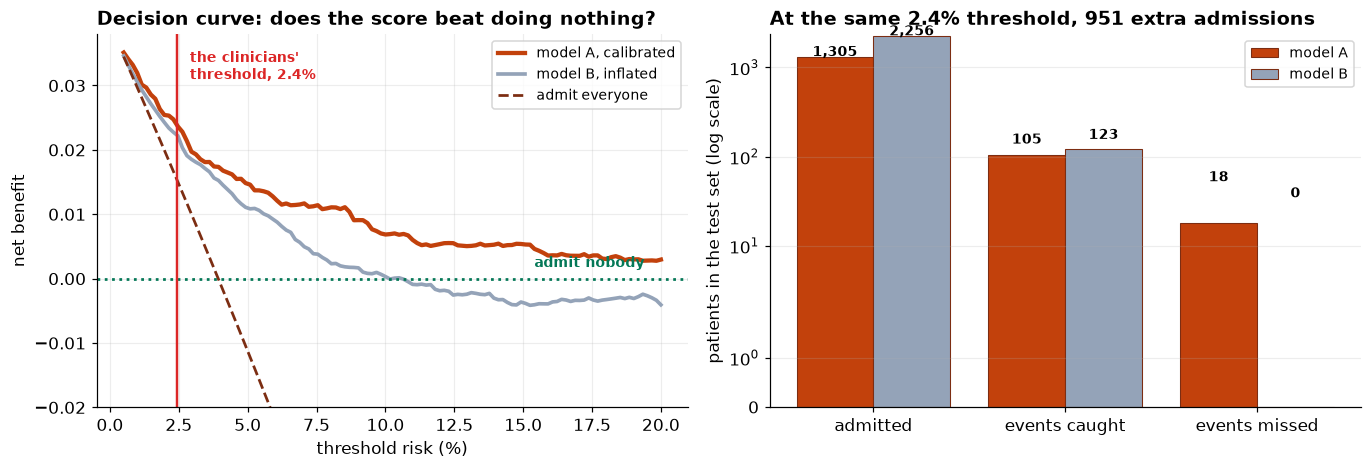

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))

ax = axes[0]
ts = np.linspace(0.005, 0.20, 120)
nbA = [net_benefit(pA, yte, t_) for t_ in ts]
nbB = [net_benefit(pB, yte, t_) for t_ in ts]
nbAll = [yte.mean() - (1-yte.mean())*(t_/(1-t_)) for t_ in ts]
ax.plot(ts*100, nbA, color=OR, lw=2.8, label="model A, calibrated")
ax.plot(ts*100, nbB, color=MUT, lw=2.4, label="model B, inflated")
ax.plot(ts*100, nbAll, color=DK, lw=1.8, ls="--", label="admit everyone")
ax.axhline(0, color=GD, lw=1.8, ls=":")
ax.text(19.4, 0.0018, "admit nobody", ha="right", color=GD, fontsize=9, fontweight="bold")
ax.axvline(2.44, color=RD, lw=1.6)
ax.text(2.9, 0.031, "the clinicians'\nthreshold, 2.4%", color=RD, fontsize=9, fontweight="bold")
ax.set_xlabel("threshold risk (%)"); ax.set_ylabel("net benefit")
ax.set_ylim(-0.02, 0.038); ax.set_title("Decision curve: does the score beat doing nothing?")
ax.legend(fontsize=9, loc="upper right")

ax = axes[1]
labs = ["admitted", "events caught", "events missed"]
a_vals = [res["model A, calibrated"][0], res["model A, calibrated"][1], res["model A, calibrated"][2]]
b_vals = [res["model B, inflated"][0], res["model B, inflated"][1], res["model B, inflated"][2]]
xs = np.arange(3)
ax.bar(xs-0.2, a_vals, 0.4, color=OR, edgecolor=DK, lw=0.7, label="model A")
ax.bar(xs+0.2, b_vals, 0.4, color=MUT, edgecolor=DK, lw=0.7, label="model B")
for i, (a_, b_) in enumerate(zip(a_vals, b_vals)):
    ax.text(i-0.2, a_+35, f"{a_:,}", ha="center", fontweight="bold", fontsize=9)
    ax.text(i+0.2, b_+35, f"{b_:,}", ha="center", fontweight="bold", fontsize=9)
ax.set_xticks(xs); ax.set_xticklabels(labs); ax.set_yscale("symlog")
ax.set_ylabel("patients in the test set (log scale)")
ax.set_title(f"At the same 2.4% threshold, {extra_adm} extra admissions")
ax.legend(fontsize=9); ax.grid(axis="x", alpha=0)
plt.tight_layout(); plt.show()

**Left:** net benefit across every threshold a clinician might hold. Model A is above model B throughout, and both are above the two trivial strategies in the region that matters. **Right:** the same threshold applied to both models. Model B misses no events and admits 951 more people to do it, which is fifty-three extra admissions for each extra event, against a stated tolerance of forty.

## Step 11 &middot; Ethics, bias, and limits
- **Report calibration next to discrimination, always.** AUC answers a question about ranking and is quoted as though it answered a question about risk. If a model card gives only AUC, the model has not been evaluated for the thing it will be used for.
- **A threshold is a clinical decision, not a statistical one.** Youden's index and "the elbow of the curve" both encode a cost ratio, silently, and neither of them asked anybody what that ratio should be.
- **A miscalibrated model overrides the clinical team without telling them.** Model B does not miss events, and it purchases that by admitting patients at a trade-off nobody agreed to. Calibration error does not look like error; it looks like caution.
- **Never quote accuracy on an imbalanced outcome.** Sending everybody home scores 96.1 percent here.
- **Validate on data the model has never seen, and say so.** A decoy variable with no real effect improves training performance every single time.
- **A risk score is not a diagnosis.** It estimates a rate in a group of similar patients, and no individual has a 4 percent event. The score belongs alongside clinical judgment, not in place of it.
- **Check who the model works for.** This analysis reports one AUC and one calibration curve for the whole cohort. Performance can differ substantially by age, sex or ethnicity, and a score that is well calibrated on average can be badly calibrated for a subgroup that the average conceals. Capstone 33 takes that up directly.

---
**From analysis to report.** The notebook carries the chain: the decision the score serves, the cleaning and the indicator that kept 138 patients in, a held-out test set, two models with the same AUC and very different risks, the calibration slope and intercept that tell them apart, the accuracy trap, a threshold derived from a stated cost ratio, the admissions each model produces at that threshold, decision curve analysis across the range clinicians disagree over, and a decoy variable that earns nothing. The written reports turn it into guidance a clinical lead can act on and a technical account a fellow statistician can audit. Automate the evidence; author the argument.